# KMeans Clustering Polutan di Gresik

## 1. Modelling

### 1.1 Clustering dengan K-Means

Data yang telah melalui tahap persiapan selanjutnya dikelompokkan menggunakan algoritma K-Means. Proses clustering dilakukan untuk mengelompokkan daerah berdasarkan kemiripan karakteristik data polutan.

Sebelum clustering, ada beberapa langkah yang dilakukan:

1. **Menentukan jumlah cluster.** Beberapa nilai $k$ diuji untuk mengetahui jumlah kelompok yang sesuai berdasarkan hasil evaluasi.

2. **Menentukan anggota cluster.** K-Means mengelompokkan setiap data berdasarkan jaraknya terhadap *centroid* dari masing-masing cluster.

3. **Mengevaluasi hasil clustering.** Hasil pengelompokan dinilai menggunakan *silhouette score* untuk mengetahui kualitas pemisahan antar-cluster.

4. **Menampilkan hasil clustering.** Hasil pengelompokan divisualisasikan menggunakan Scatter Plot untuk melihat persebaran daerah pada setiap cluster.

Proses clustering diterapkan pada data **NO2, SO2, dan CO** untuk melihat pola pengelompokan daerah berdasarkan karakteristik masing-masing polutan.



### 1.2 Clustering dengan Python (Scikit-Learn)

Pengelompokan dijalankan dengan *library* **Scikit-Learn** (`sklearn`), yang menyediakan `StandardScaler`, `PCA`, dan `KMeans`. Tiap polutan diproses sendiri-sendiri dengan langkah yang sama, sehingga langkah tersebut dibungkus menjadi fungsi agar tidak perlu menuliskan kode yang sama tiga kali.


#### 1.2.1 Evaluasi Jumlah Cluster

Sebelum menjalankan K-Means final, jumlah cluster terlebih dahulu dievaluasi menggunakan **Elbow Method** dan **Silhouette Score**. Pengujian dilakukan pada $K=2$ sampai $K=10$ untuk setiap jenis polutan.

Evaluasi dilakukan pada dua kondisi agar dapat dibandingkan pengaruh reduksi dimensi terhadap hasil clustering, yaitu:
1. **Tanpa PCA**, menggunakan seluruh 68 fitur hasil ekstraksi TSFEL.
2. **Dengan PCA**, menggunakan hasil reduksi dimensi menjadi 37 komponen utama.

Elbow Method digunakan dengan melihat perubahan nilai *inertia*, sedangkan Silhouette Score digunakan untuk mengetahui seberapa baik pemisahan data antar-cluster. Nilai silhouette yang lebih tinggi menunjukkan pemisahan cluster yang lebih baik. Untuk setiap kondisi, K dengan Silhouette Score tertinggi dipilih sebagai K terbaik pada kondisi tersebut.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def evaluasi_cluster(file_csv, nama_polutan, n_dimensi_pca=37, k_range=range(2, 11)):
    data = pd.read_csv(file_csv)

    kolom_identitas = ["id", "nama", "daerah"]
    identitas = data[kolom_identitas].copy()
    X = data.drop(columns=kolom_identitas)

    # Standardisasi fitur (kondisi tanpa PCA, 68 fitur)
    X_scaled = StandardScaler().fit_transform(X)

    # Reduksi dimensi dengan PCA (kondisi dengan PCA, 37 komponen)
    X_pca = PCA(n_components=n_dimensi_pca, random_state=42).fit_transform(X_scaled)

    def _evaluasi_kmeans(X_input):
        inertia, silhouette = [], []
        for k in k_range:
            model = KMeans(
                n_clusters=k,
                n_init=10,
                random_state=42
            )
            label = model.fit_predict(X_input)
            inertia.append(model.inertia_)
            silhouette.append(silhouette_score(X_input, label))

        return pd.DataFrame({
            "K": list(k_range),
            "Inertia": inertia,
            "Silhouette": silhouette
        })

    # Evaluasi K=2..10 pada kedua kondisi
    hasil_tanpa_pca = _evaluasi_kmeans(X_scaled)
    hasil_dengan_pca = _evaluasi_kmeans(X_pca)

    k_tanpa_pca = int(
        hasil_tanpa_pca.loc[hasil_tanpa_pca["Silhouette"].idxmax(), "K"]
    )
    k_dengan_pca = int(
        hasil_dengan_pca.loc[hasil_dengan_pca["Silhouette"].idxmax(), "K"]
    )

    print(f"\n=== Evaluasi Cluster {nama_polutan} - TANPA PCA ({X_scaled.shape[1]} fitur) ===")
    print(hasil_tanpa_pca.to_string(index=False))
    print(f"K dengan Silhouette Score tertinggi (tanpa PCA): {k_tanpa_pca}")

    print(f"\n=== Evaluasi Cluster {nama_polutan} - DENGAN PCA ({X_pca.shape[1]} komponen) ===")
    print(hasil_dengan_pca.to_string(index=False))
    print(f"K dengan Silhouette Score tertinggi (dengan PCA): {k_dengan_pca}")

    # Visualisasi Elbow Method & Silhouette Score untuk kedua kondisi
    def _plot_evaluasi(hasil, judul):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        axes[0].plot(
            hasil["K"],
            hasil["Inertia"],
            marker="o",
            linestyle="--"
        )
        axes[0].set_title(f"Elbow Method - {judul}")
        axes[0].set_xlabel("Jumlah Cluster (K)")
        axes[0].set_ylabel("Inertia")
        axes[0].grid(True)

        axes[1].plot(
            hasil["K"],
            hasil["Silhouette"],
            marker="o",
            linestyle="--"
        )
        axes[1].set_title(f"Silhouette Score - {judul}")
        axes[1].set_xlabel("Jumlah Cluster (K)")
        axes[1].set_ylabel("Silhouette Score")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    _plot_evaluasi(hasil_tanpa_pca, f"{nama_polutan} - Tanpa PCA")
    _plot_evaluasi(hasil_dengan_pca, f"{nama_polutan} - Dengan PCA ({n_dimensi_pca} Komponen)")

    return {
        "identitas": identitas,
        "X_scaled": X_scaled,
        "X_pca": X_pca,
        "hasil_tanpa_pca": hasil_tanpa_pca,
        "hasil_dengan_pca": hasil_dengan_pca,
        "k_tanpa_pca": k_tanpa_pca,
        "k_dengan_pca": k_dengan_pca,
    }


=== Evaluasi Cluster NO2 - TANPA PCA (68 fitur) ===
 K     Inertia  Silhouette
 2 1326.578705    0.745489
 3 1001.281921    0.190722
 4  811.798641    0.204530
 5  655.789824    0.216606
 6  578.312417    0.185596
 7  504.989692    0.161947
 8  458.598752    0.166889
 9  424.658844    0.151594
10  373.027966    0.172124
K dengan Silhouette Score tertinggi (tanpa PCA): 2

=== Evaluasi Cluster NO2 - DENGAN PCA (37 komponen) ===
 K     Inertia  Silhouette
 2 1326.578705    0.745489
 3 1001.281921    0.190722
 4  811.798641    0.204530
 5  655.789824    0.216606
 6  578.312417    0.185596
 7  504.989692    0.161947
 8  458.598752    0.166889
 9  424.658844    0.151594
10  373.027966    0.172124
K dengan Silhouette Score tertinggi (dengan PCA): 2


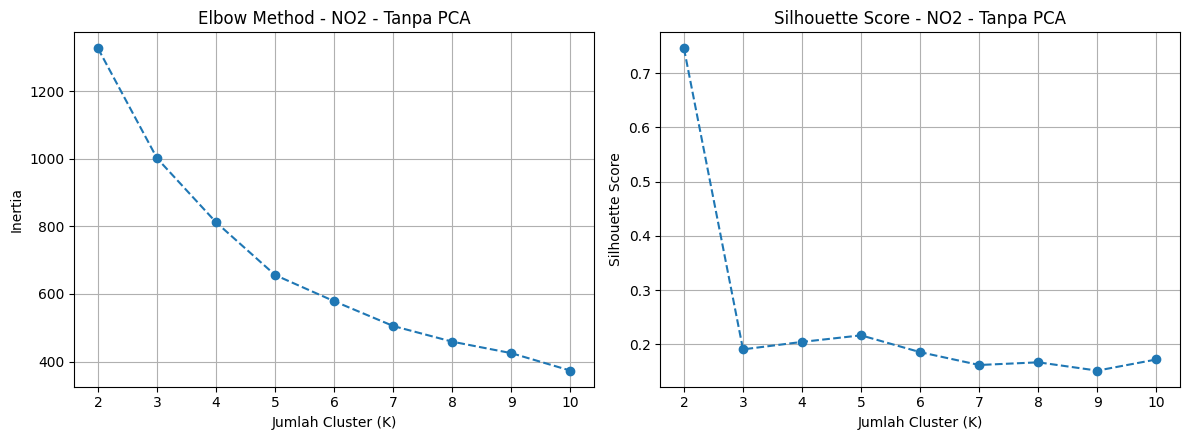

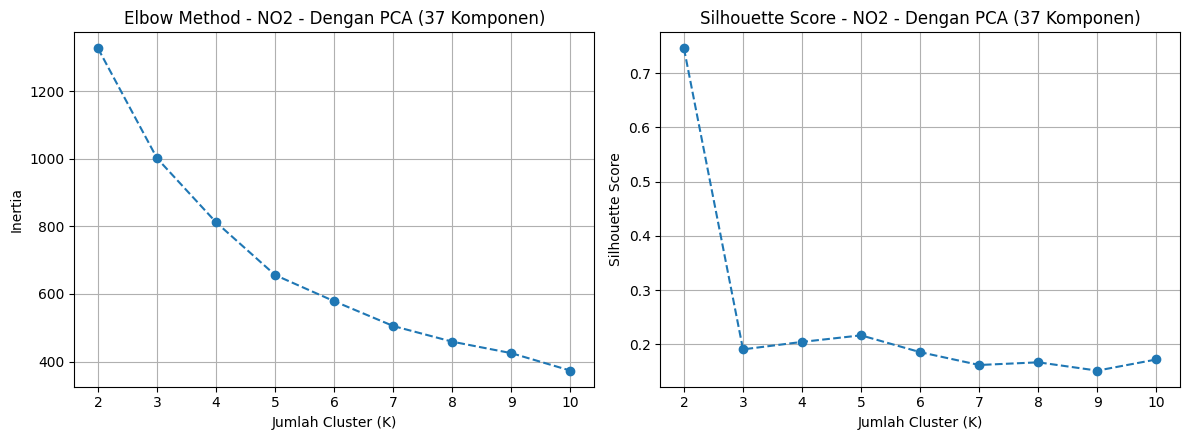


=== Evaluasi Cluster SO2 - TANPA PCA (68 fitur) ===
 K     Inertia  Silhouette
 2 1210.459866    0.789366
 3  691.644801    0.708469
 4  525.289021    0.392088
 5  413.678733    0.406057
 6  335.555572    0.135855
 7  301.063844    0.126801
 8  267.415808    0.099564
 9  239.817616    0.120845
10  230.171524    0.092438
K dengan Silhouette Score tertinggi (tanpa PCA): 2

=== Evaluasi Cluster SO2 - DENGAN PCA (37 komponen) ===
 K     Inertia  Silhouette
 2 1210.459866    0.789366
 3  691.644801    0.708469
 4  525.289021    0.392088
 5  413.678733    0.406057
 6  335.555572    0.135855
 7  301.063844    0.126801
 8  267.415808    0.099564
 9  239.817616    0.120845
10  230.171524    0.092438
K dengan Silhouette Score tertinggi (dengan PCA): 2


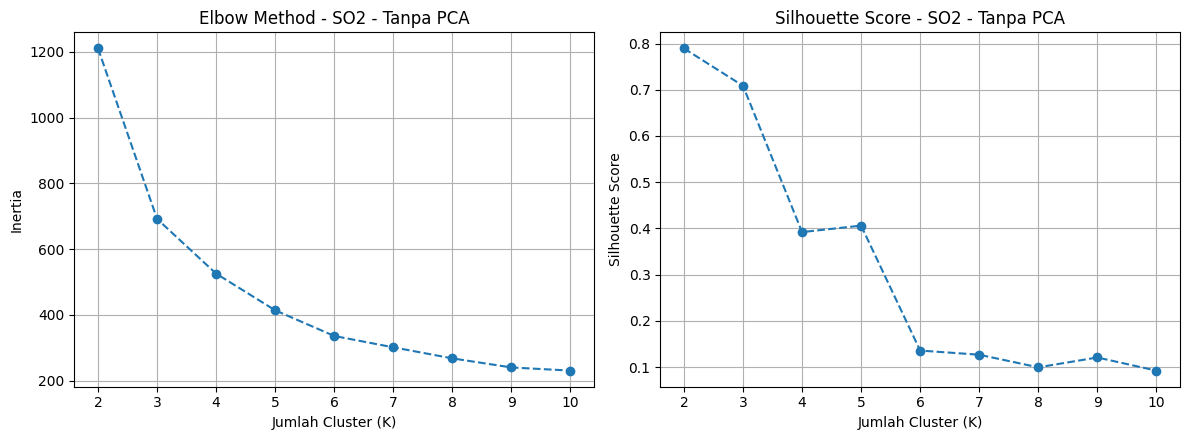

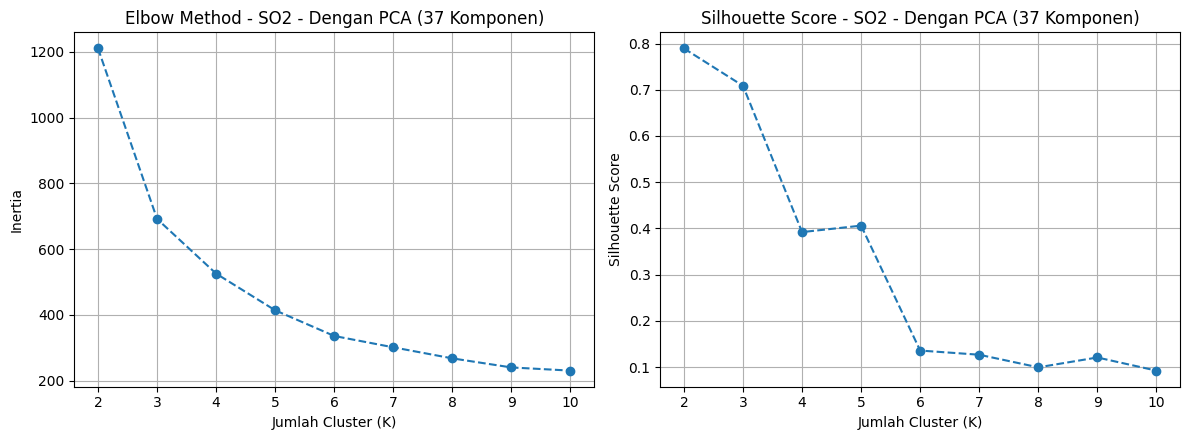


=== Evaluasi Cluster CO - TANPA PCA (68 fitur) ===
 K     Inertia  Silhouette
 2 1123.800303    0.795494
 3  660.214101    0.697034
 4  509.373825    0.342517
 5  413.889526    0.184501
 6  361.351576    0.153812
 7  315.868398    0.161337
 8  272.854136    0.142490
 9  239.322559    0.150055
10  221.039012    0.145469
K dengan Silhouette Score tertinggi (tanpa PCA): 2

=== Evaluasi Cluster CO - DENGAN PCA (37 komponen) ===
 K     Inertia  Silhouette
 2 1123.800303    0.795494
 3  660.214101    0.697034
 4  509.373825    0.342517
 5  413.889526    0.184501
 6  361.351576    0.153812
 7  315.868398    0.161337
 8  272.854136    0.142490
 9  239.322559    0.150055
10  221.039012    0.145469
K dengan Silhouette Score tertinggi (dengan PCA): 2


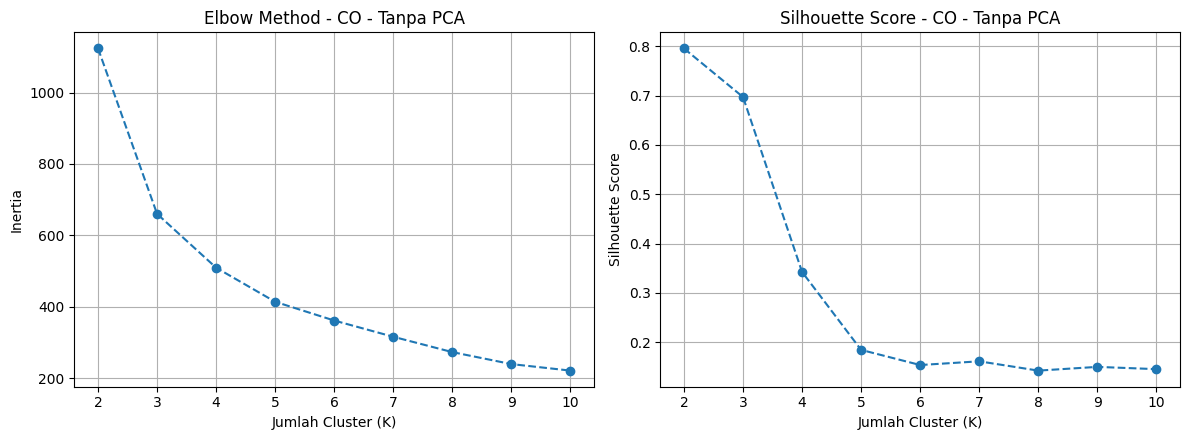

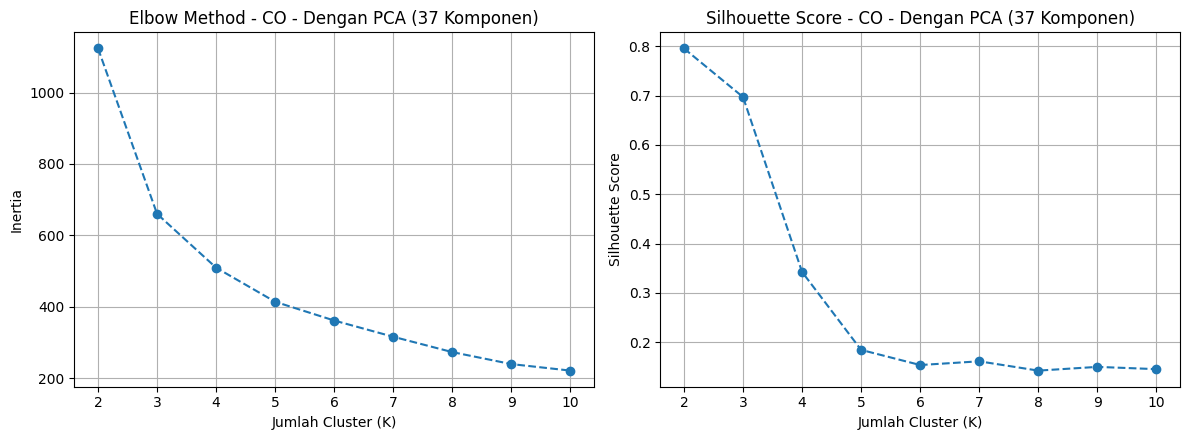

In [13]:
hasil_no2 = evaluasi_cluster(
    "ekstraksi_fitur_no2.csv",
    "NO2"
)

hasil_so2 = evaluasi_cluster(
    "ekstraksi_fitur_so2.csv",
    "SO2"
)

hasil_co = evaluasi_cluster(
    "ekstraksi_fitur_co.csv",
    "CO"
)

#### 1.2.2 Ringkasan Perbandingan Tanpa PCA vs Dengan PCA

Tabel berikut merangkum **K terbaik** (K dengan Silhouette Score tertinggi) beserta nilai Silhouette Score-nya untuk setiap polutan, pada kondisi **tanpa PCA (68 fitur)** dan **dengan PCA (37 komponen)**. Ringkasan ini digunakan untuk melihat pengaruh reduksi dimensi terhadap kualitas pemisahan cluster, sebelum K-Means final dijalankan pada bagian 4.3.


In [14]:
ringkasan_k = []

for nama_polutan, hasil in [("NO2", hasil_no2), ("SO2", hasil_so2), ("CO", hasil_co)]:
    baris_tanpa_pca = hasil["hasil_tanpa_pca"].loc[
        hasil["hasil_tanpa_pca"]["Silhouette"].idxmax()
    ]
    baris_dengan_pca = hasil["hasil_dengan_pca"].loc[
        hasil["hasil_dengan_pca"]["Silhouette"].idxmax()
    ]

    ringkasan_k.extend([
        {
            "Polutan": nama_polutan,
            "Kondisi": "Tanpa PCA",
            "Jumlah Fitur": hasil["X_scaled"].shape[1],
            "K Terbaik": int(baris_tanpa_pca["K"]),
            "Silhouette Score": float(baris_tanpa_pca["Silhouette"]),
        },
        {
            "Polutan": nama_polutan,
            "Kondisi": "Dengan PCA",
            "Jumlah Fitur": hasil["X_pca"].shape[1],
            "K Terbaik": int(baris_dengan_pca["K"]),
            "Silhouette Score": float(baris_dengan_pca["Silhouette"]),
        },
    ])

ringkasan_k = pd.DataFrame(ringkasan_k)
print(ringkasan_k.to_string(index=False))

Polutan    Kondisi  Jumlah Fitur  K Terbaik  Silhouette Score
    NO2  Tanpa PCA            68          2          0.745489
    NO2 Dengan PCA            37          2          0.745489
    SO2  Tanpa PCA            68          2          0.789366
    SO2 Dengan PCA            37          2          0.789366
     CO  Tanpa PCA            68          2          0.795494
     CO Dengan PCA            37          2          0.795494


### 1.3 K-Means Final, Distribusi Cluster, dan Profil Daerah

Berdasarkan ringkasan pada bagian 4.2.2, K-Means final dijalankan menggunakan **K terbaik pada kondisi dengan PCA** untuk masing-masing polutan, karena reduksi dimensi dengan PCA juga digunakan pada alur implementasi KNIME (lihat bagian 4.5). Hasil pengelompokan kemudian digabungkan dengan informasi daerah, ditampilkan melalui Scatter Plot, dan dirangkum dalam bentuk **distribusi jumlah anggota tiap cluster** serta **profil daerah** pada tiap cluster.

#### 1.3.1 NO2

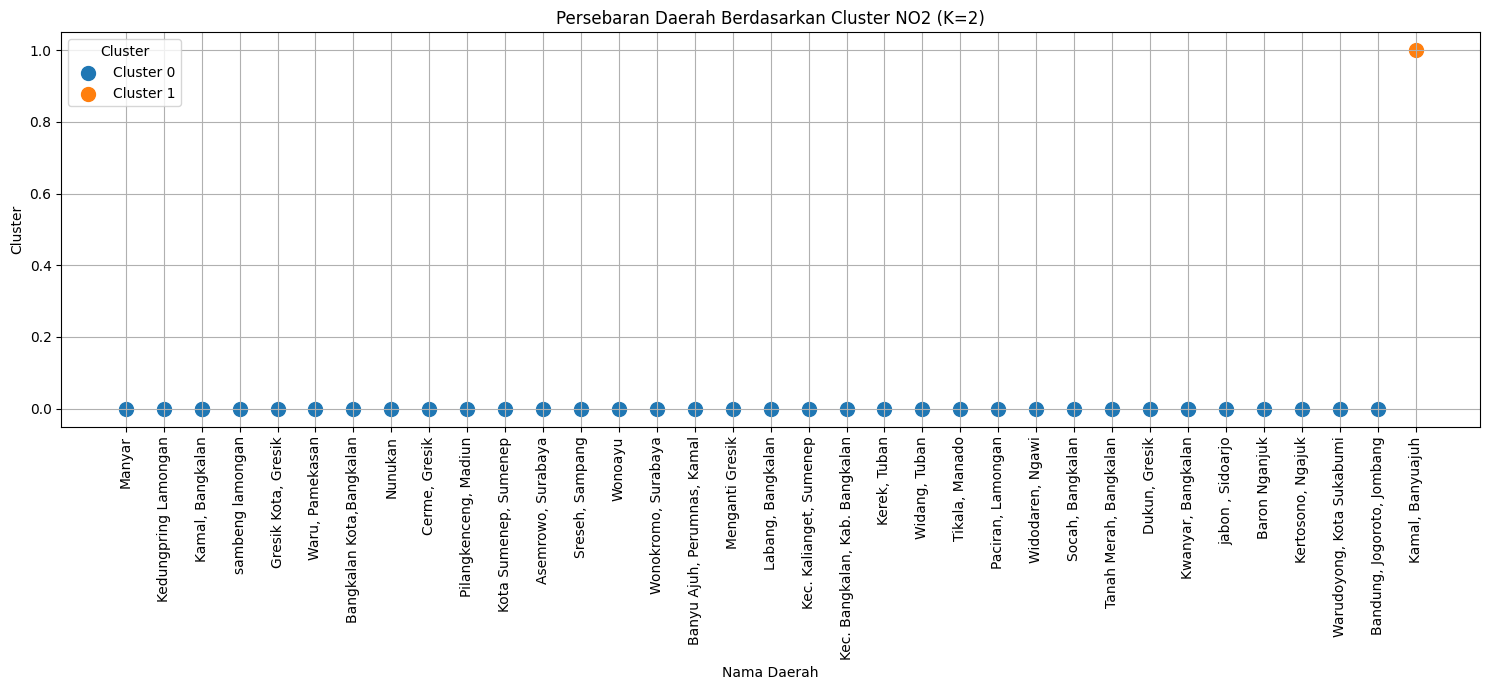


Distribusi anggota cluster NO2 (K=2):
cluster_label
cluster_0    36
cluster_1     1
Name: count, dtype: int64

Profil daerah teratas per cluster NO2 (K=2):
    Cluster              daerah  Jumlah
8         0    Kamal, Bangkalan       2
15        0  Kwanyar, Bangkalan       2
0         0  Asemrowo, Surabaya       1
34        1    Kamal, Banyuajuh       1


In [15]:
# Menggunakan kembali hasil identitas & X_pca dari tahap evaluasi (4.2.1)
identitas_no2 = hasil_no2["identitas"]
X_no2_pca = hasil_no2["X_pca"]
k_final_no2 = hasil_no2["k_dengan_pca"]

# Menjalankan K-Means final menggunakan K terbaik (kondisi dengan PCA)
model_no2 = KMeans(
    n_clusters=k_final_no2,
    n_init=10,
    random_state=42
)

label_no2 = model_no2.fit_predict(X_no2_pca)

hasil_final_no2 = identitas_no2.copy()
hasil_final_no2["Cluster"] = label_no2
hasil_final_no2["cluster_label"] = "cluster_" + hasil_final_no2["Cluster"].astype(str)

# Visualisasi hasil pengelompokan
plt.figure(figsize=(15, 7))

for cluster in sorted(hasil_final_no2["Cluster"].unique()):
    data_cluster = hasil_final_no2[hasil_final_no2["Cluster"] == cluster]
    plt.scatter(
        data_cluster["daerah"],
        data_cluster["Cluster"],
        label=f"Cluster {cluster}",
        s=100
    )

plt.title(f"Persebaran Daerah Berdasarkan Cluster NO2 (K={k_final_no2})")
plt.xlabel("Nama Daerah")
plt.ylabel("Cluster")
plt.xticks(rotation=90)
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Distribusi jumlah anggota setiap cluster
print(f"\nDistribusi anggota cluster NO2 (K={k_final_no2}):")
print(hasil_final_no2["cluster_label"].value_counts().sort_index())

# Ringkasan jumlah data pada setiap daerah dan cluster
profil_no2 = (
    hasil_final_no2
    .groupby(["Cluster", "daerah"])
    .size()
    .reset_index(name="Jumlah")
)

profil_no2 = profil_no2.sort_values(
    ["Cluster", "Jumlah"],
    ascending=[True, False]
)

print(f"\nProfil daerah teratas per cluster NO2 (K={k_final_no2}):")
print(profil_no2.groupby("Cluster").head(3))

Tabel distribusi menunjukkan jumlah daerah pada setiap cluster hasil K-Means final untuk NO2, sedangkan tabel profil menampilkan tiga daerah dengan jumlah data terbanyak pada masing-masing cluster. Cluster dengan jumlah anggota yang jauh lebih sedikit dibandingkan cluster lain perlu diperhatikan secara khusus karena berpotensi menunjukkan karakteristik konsentrasi NO2 yang berbeda dari mayoritas daerah.


#### 1.3.2 SO2

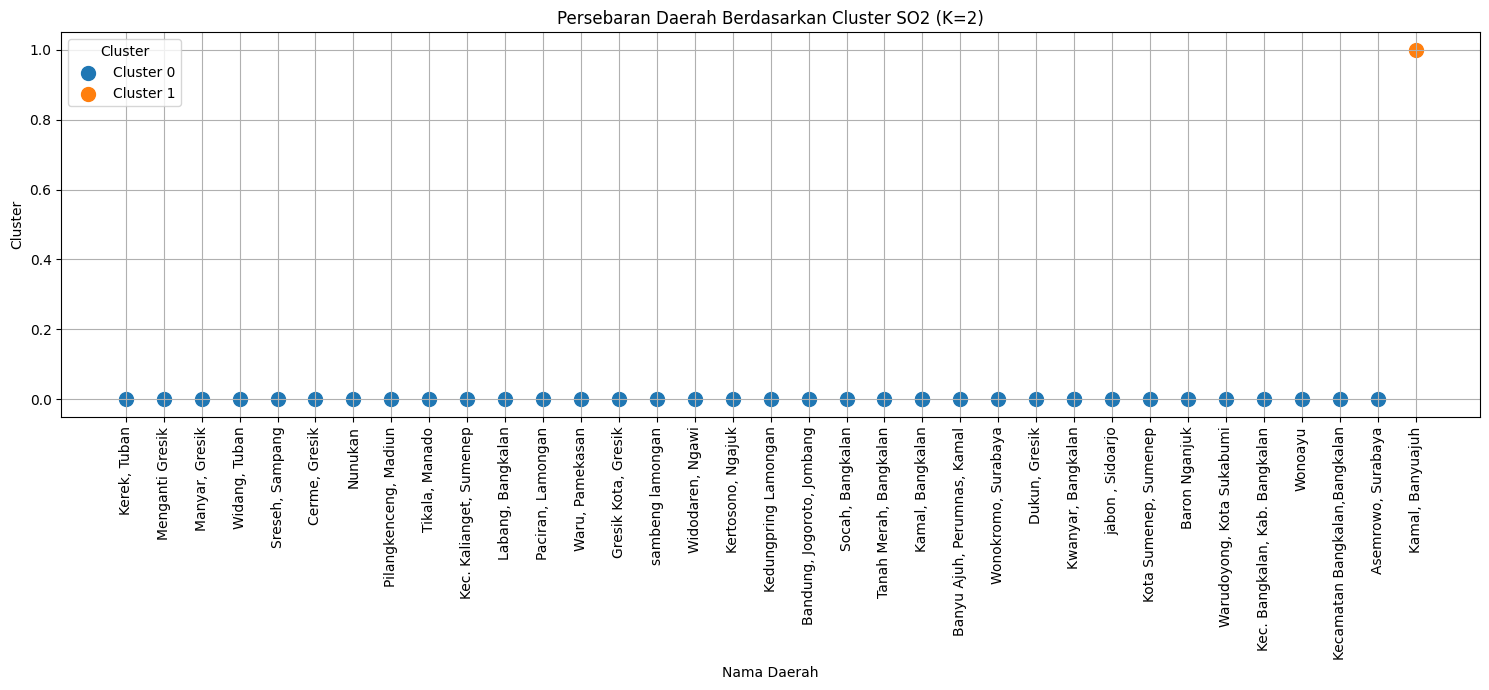


Distribusi anggota cluster SO2 (K=2):
cluster_label
cluster_0    36
cluster_1     1
Name: count, dtype: int64

Profil daerah teratas per cluster SO2 (K=2):
    Cluster              daerah  Jumlah
7         0    Kamal, Bangkalan       2
15        0  Kwanyar, Bangkalan       2
0         0  Asemrowo, Surabaya       1
34        1    Kamal, Banyuajuh       1


In [16]:
# Menggunakan kembali hasil identitas & X_pca dari tahap evaluasi (4.2.1)
identitas_so2 = hasil_so2["identitas"]
X_so2_pca = hasil_so2["X_pca"]
k_final_so2 = hasil_so2["k_dengan_pca"]

# Menjalankan K-Means final menggunakan K terbaik (kondisi dengan PCA)
km_so2 = KMeans(
    n_clusters=k_final_so2,
    n_init=10,
    random_state=42
)

cluster_so2 = km_so2.fit_predict(X_so2_pca)

hasil_final_so2 = identitas_so2.copy()
hasil_final_so2["Cluster"] = cluster_so2
hasil_final_so2["cluster_label"] = "cluster_" + hasil_final_so2["Cluster"].astype(str)

# Visualisasi cluster berdasarkan daerah
plt.figure(figsize=(15, 7))

for c in sorted(hasil_final_so2["Cluster"].unique()):
    subset = hasil_final_so2.loc[hasil_final_so2["Cluster"] == c]

    plt.scatter(
        subset["daerah"],
        subset["Cluster"],
        s=100,
        label=f"Cluster {c}"
    )

plt.title(f"Persebaran Daerah Berdasarkan Cluster SO2 (K={k_final_so2})")
plt.xlabel("Nama Daerah")
plt.ylabel("Cluster")
plt.xticks(rotation=90)
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Distribusi jumlah anggota setiap cluster
print(f"\nDistribusi anggota cluster SO2 (K={k_final_so2}):")
print(hasil_final_so2["cluster_label"].value_counts().sort_index())

# Profil tiga daerah dengan jumlah data terbanyak pada setiap cluster
profil_so2 = (
    hasil_final_so2
    .groupby(["Cluster", "daerah"])
    .size()
    .reset_index(name="Jumlah")
)

profil_so2 = profil_so2.sort_values(
    by=["Cluster", "Jumlah"],
    ascending=[True, False]
)

print(f"\nProfil daerah teratas per cluster SO2 (K={k_final_so2}):")
print(profil_so2.groupby("Cluster").head(3))

Tabel distribusi menunjukkan jumlah daerah pada setiap cluster hasil K-Means final untuk SO2, sedangkan tabel profil menampilkan tiga daerah dengan jumlah data terbanyak pada masing-masing cluster. Cluster dengan jumlah anggota yang jauh lebih sedikit dibandingkan cluster lain perlu diperhatikan secara khusus karena berpotensi menunjukkan karakteristik konsentrasi SO2 yang berbeda dari mayoritas daerah.


#### 1.3.3 CO

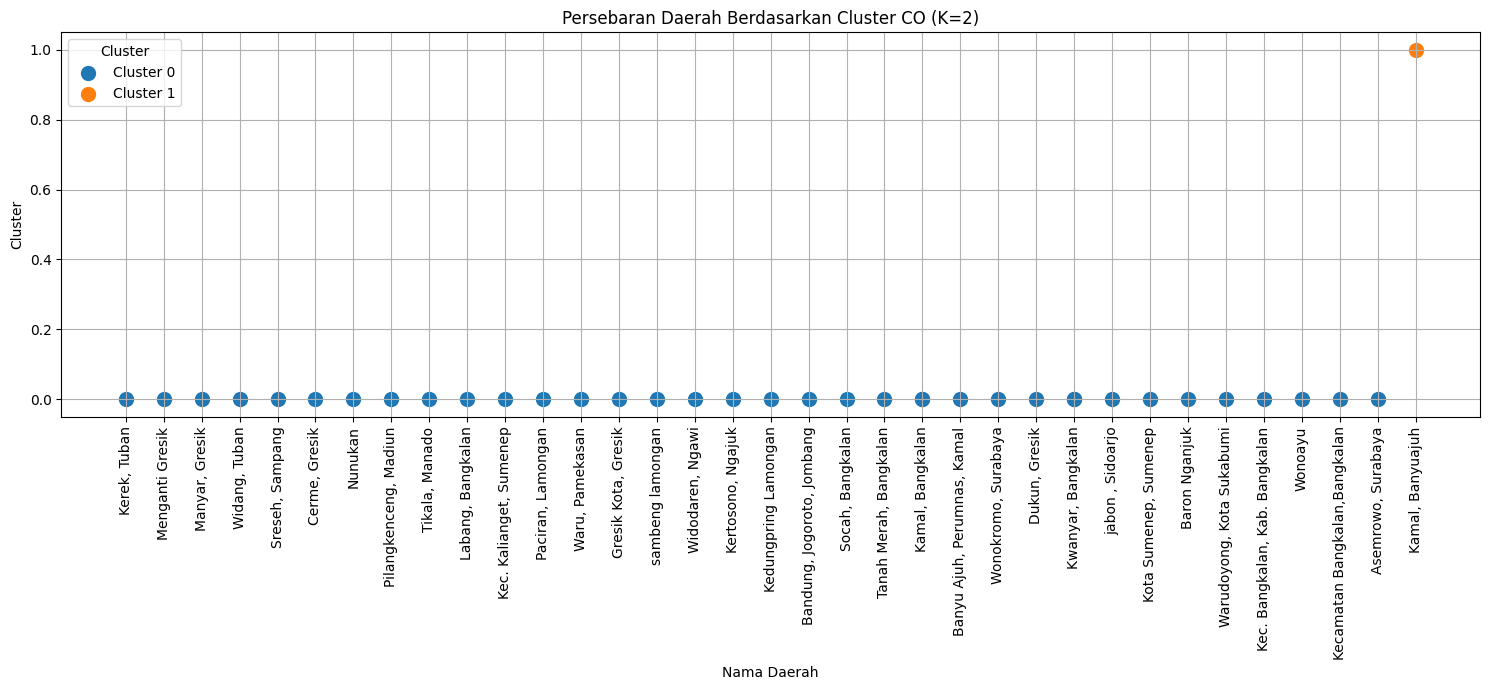


Distribusi anggota cluster CO (K=2):
cluster_label
cluster_0    36
cluster_1     1
Name: count, dtype: int64

Profil daerah teratas per cluster CO (K=2):
    Cluster              daerah  Jumlah
7         0    Kamal, Bangkalan       2
15        0  Kwanyar, Bangkalan       2
0         0  Asemrowo, Surabaya       1
34        1    Kamal, Banyuajuh       1


In [17]:
# Menggunakan kembali hasil identitas & X_pca dari tahap evaluasi (4.2.1)
identitas_co = hasil_co["identitas"]
X_co_pca = hasil_co["X_pca"]
k_final_co = hasil_co["k_dengan_pca"]

# Menjalankan K-Means final menggunakan K terbaik (kondisi dengan PCA)
cluster_co_model = KMeans(
    n_clusters=k_final_co,
    random_state=42,
    n_init=10
)

label_co = cluster_co_model.fit_predict(X_co_pca)

hasil_final_co = identitas_co.copy()
hasil_final_co["Cluster"] = label_co
hasil_final_co["cluster_label"] = "cluster_" + hasil_final_co["Cluster"].astype(str)

# Membuat Scatter Plot
plt.figure(figsize=(15, 7))

for nomor_cluster in sorted(hasil_final_co["Cluster"].unique()):
    bagian = hasil_final_co[hasil_final_co["Cluster"] == nomor_cluster]

    plt.scatter(
        bagian["daerah"],
        bagian["Cluster"],
        s=100,
        label=f"Cluster {nomor_cluster}"
    )

plt.title(f"Persebaran Daerah Berdasarkan Cluster CO (K={k_final_co})")
plt.xlabel("Nama Daerah")
plt.ylabel("Cluster")
plt.xticks(rotation=90)
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# Distribusi jumlah anggota setiap cluster
print(f"\nDistribusi anggota cluster CO (K={k_final_co}):")
print(hasil_final_co["cluster_label"].value_counts().sort_index())

# Mengambil tiga daerah teratas pada setiap cluster
profil_co = (
    hasil_final_co.groupby(["Cluster", "daerah"])
    .size()
    .reset_index(name="Jumlah")
    .sort_values(["Cluster", "Jumlah"], ascending=[True, False])
)

print(f"\nProfil daerah teratas per cluster CO (K={k_final_co}):")
print(profil_co.groupby("Cluster").head(3))

Tabel distribusi menunjukkan jumlah daerah pada setiap cluster hasil K-Means final untuk CO, sedangkan tabel profil menampilkan tiga daerah dengan jumlah data terbanyak pada masing-masing cluster. Cluster dengan jumlah anggota yang jauh lebih sedikit dibandingkan cluster lain perlu diperhatikan secara khusus karena berpotensi menunjukkan karakteristik konsentrasi CO yang berbeda dari mayoritas daerah.


### 1.4 Menyimpan Data CSV ke Database Aiven PostgreSQL

Data hasil ekstraksi fitur dari tiga polutan, yaitu NO2, SO2, dan CO, dari satu kelas kemudian dimasukkan ke database Aiven PostgreSQL menggunakan Google Colab. Proses dilakukan dengan membaca file hasil ekstraksi menggunakan Pandas dan membuat koneksi ke database menggunakan SQLAlchemy.

In [18]:
# membaca ulang CSV ekstraksi_fitur_no2.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("ekstraksi_fitur_no2.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("ekstraksi_fitur_no2", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "ekstraksi_fitur_no2" LIMIT 5', engine))

Berhasil! 37 baris terupload ke Aiven.
   id                      nama                daerah    abs_energy       auc  \
0   7   Okan Syailendra wahyudi                Manyar  1.933040e-06  0.023990   
1  10  Triswanti Jannatul Ma'wa  Kedungpring Lamongan  3.702058e-07  0.010905   
2  12           Laila Maghfiroh      Kamal, Bangkalan  7.363589e-07  0.015059   
3  13              Dedy Nurohim      sambeng lamongan  3.854020e-07  0.011228   
4  14     Ahmad Syahrul Farihin   Gresik Kota, Gresik  1.523980e-06  0.022417   

   autocorr  average_power  calc_centroid  calc_max  calc_mean  ...  \
0         7   5.310551e-09     186.075084  0.000168   0.000066  ...   
1         8   1.014262e-09     194.285209  0.000059   0.000030  ...   
2        11   2.017422e-09     166.039562  0.000086   0.000041  ...   
3         6   1.055896e-09     196.838820  0.000062   0.000031  ...   
4         3   4.175288e-09     184.039735  0.000124   0.000061  ...   

   spectral_spread  spectral_variation  spectro

In [19]:
# membaca ulang CSV ekstraksi_fitur_co.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("ekstraksi_fitur_co.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("ekstraksi_fitur_co", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "ekstraksi_fitur_no2" LIMIT 5', engine))

Berhasil! 37 baris terupload ke Aiven.
   id                      nama                daerah    abs_energy       auc  \
0   7   Okan Syailendra wahyudi                Manyar  1.933040e-06  0.023990   
1  10  Triswanti Jannatul Ma'wa  Kedungpring Lamongan  3.702058e-07  0.010905   
2  12           Laila Maghfiroh      Kamal, Bangkalan  7.363589e-07  0.015059   
3  13              Dedy Nurohim      sambeng lamongan  3.854020e-07  0.011228   
4  14     Ahmad Syahrul Farihin   Gresik Kota, Gresik  1.523980e-06  0.022417   

   autocorr  average_power  calc_centroid  calc_max  calc_mean  ...  \
0         7   5.310551e-09     186.075084  0.000168   0.000066  ...   
1         8   1.014262e-09     194.285209  0.000059   0.000030  ...   
2        11   2.017422e-09     166.039562  0.000086   0.000041  ...   
3         6   1.055896e-09     196.838820  0.000062   0.000031  ...   
4         3   4.175288e-09     184.039735  0.000124   0.000061  ...   

   spectral_spread  spectral_variation  spectro

In [20]:
# membaca ulang CSV ekstraksi_fitur_so2.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("ekstraksi_fitur_so2.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("ekstraksi_fitur_so2", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "ekstraksi_fitur_so2" LIMIT 5', engine))

Berhasil! 37 baris terupload ke Aiven.
   id                             nama           daerah  abs_energy       auc  \
0   2                Nurhabibatul Umah     Kerek, Tuban    0.000005  0.028719   
1   3  Verdi Setyawan Ardiansyah Putra  Menganti Gresik    0.000011  0.042161   
2   4          Okan Syailendra wahyudi   Manyar, Gresik    0.000025  0.063998   
3   5          Mochammad Zaenal Abidin    Widang, Tuban    0.000004  0.026307   
4   6              M. Hendrik Purwanto  Sreseh, Sampang    0.000003  0.022927   

   autocorr  average_power  calc_centroid  calc_max  calc_mean  ...  \
0         2   1.263833e-08     209.877355  0.000309   0.000033  ...   
1         2   2.989639e-08     172.148705  0.000461   0.000087  ...   
2         1   6.807531e-08     204.258058  0.000793   0.000111  ...   
3         2   1.053692e-08     186.794715  0.000274   0.000026  ...   
4         2   9.373189e-09     210.032798  0.000293   0.000021  ...   

   spectral_spread  spectral_variation  spectro

### 1.5 Menghubungkan Database PostgreSQL Aiven dengan KNIME

Data yang telah disimpan pada database PostgreSQL Aiven selanjutnya diakses menggunakan KNIME untuk dilakukan proses clustering.

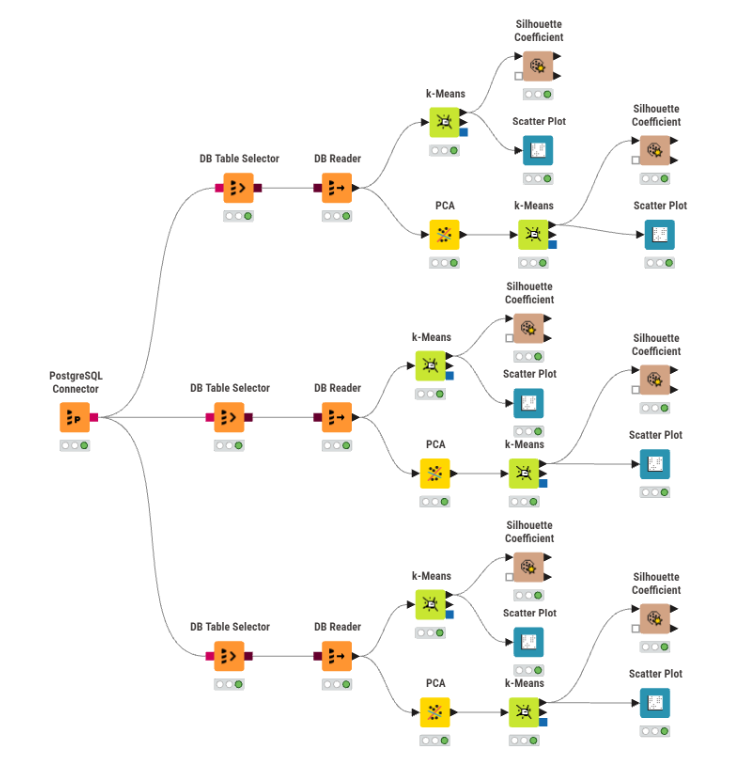

### Penjelasan Fungsi Setiap Node

1. **PostgreSQL Connector**  
   Digunakan untuk menghubungkan KNIME dengan database Aiven PostgreSQL sebagai sumber data hasil ekstraksi fitur polutan.
2. **DB Table Selector**  
   Digunakan untuk memilih tabel hasil ekstraksi fitur dari masing-masing polutan, yaitu **NO2, SO2, dan CO**.
3. **DB Reader**  
   Digunakan untuk mengambil data dari tabel PostgreSQL yang telah dipilih agar dapat diproses lebih lanjut di KNIME.
4. **k-Means (Tanpa PCA)**  
   Digunakan untuk melakukan proses clustering secara langsung menggunakan fitur yang tersedia tanpa melalui reduksi dimensi PCA. Hasilnya digunakan sebagai pembanding dengan clustering yang menggunakan PCA.
5. **PCA (Principal Component Analysis)**  
   Digunakan untuk mengurangi dimensi data dengan mengubah sejumlah fitur asli menjadi beberapa komponen utama. Hasil PCA kemudian digunakan sebagai input untuk proses k-Means.
6. **k-Means (Dengan PCA)**  
   Digunakan untuk melakukan clustering menggunakan data yang telah direduksi dimensinya melalui PCA. Jumlah cluster yang digunakan mengikuti nilai **$K$** yang telah ditentukan pada tahap penentuan jumlah cluster terbaik.
7. **Silhouette Coefficient**  
   Digunakan untuk mengevaluasi kualitas hasil clustering. Nilai Silhouette menunjukkan seberapa baik suatu data berada dalam cluster-nya dibandingkan dengan cluster lainnya. Pada workflow ini, evaluasi dilakukan pada hasil k-Means tanpa PCA dan dengan PCA.
8. **Scatter Plot**  
   Digunakan untuk memvisualisasikan hasil clustering dalam bentuk grafik pencar sehingga persebaran data dan pemisahan antar-cluster dapat diamati secara visual. Scatter Plot digunakan pada hasil k-Means tanpa PCA maupun dengan PCA.

#### 1.5.1 Analisis Hasil Clustering Polutan NO2

##### a. K = 2


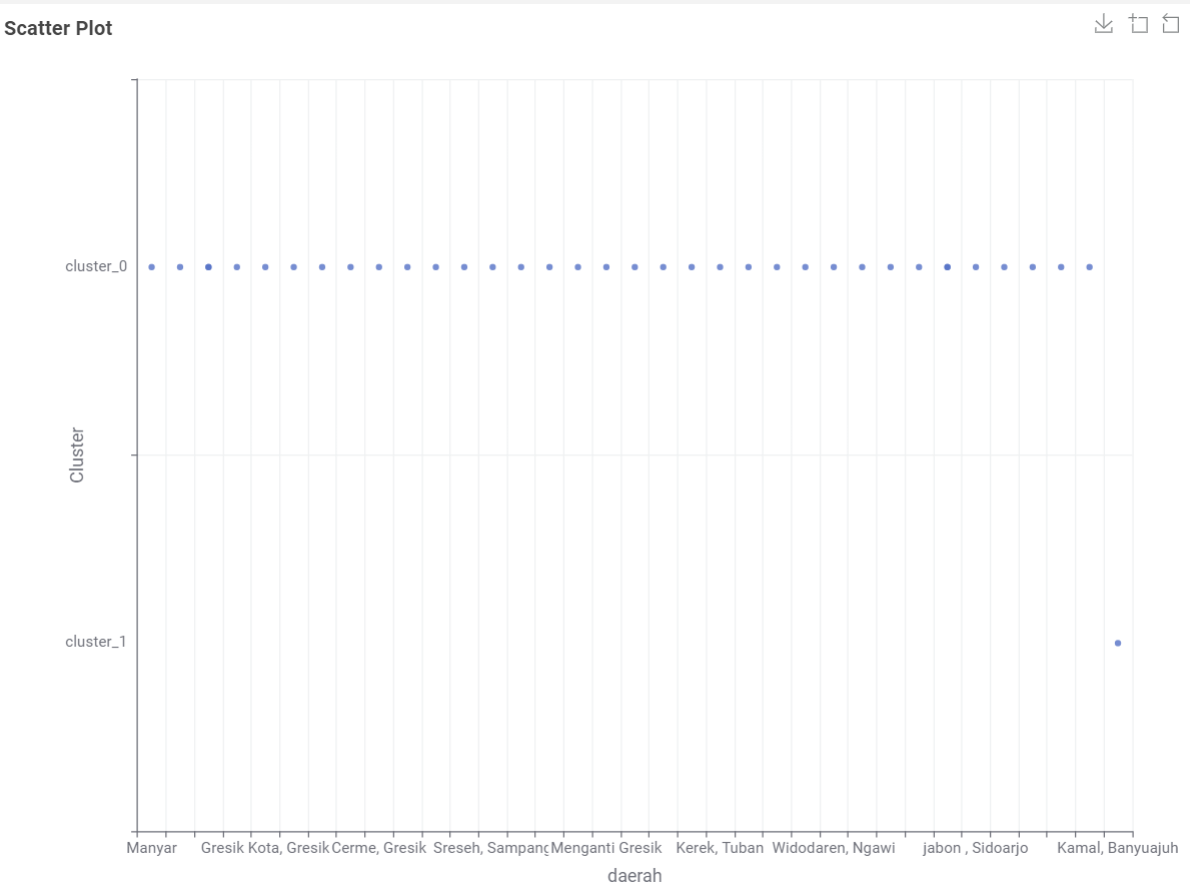

Berdasarkan Scatter Plot, hasil clustering polutan **NO2** terbagi menjadi **2 cluster**, yaitu **cluster_0** dan **cluster_1**. Persebaran titik menunjukkan bahwa sebagian besar kecamatan berada pada cluster_0, sedangkan hanya satu kecamatan yang berada pada cluster_1.

Beberapa hasil yang dapat diamati adalah:

- **Cluster_0** memiliki jumlah anggota paling banyak dan mencakup hampir seluruh kecamatan yang terdapat pada data.

- **Cluster_1** hanya memiliki satu anggota, yaitu **Banyuwangi**, yang terlihat berada pada posisi terpisah dari kecamatan lainnya.

- Sumbu horizontal menunjukkan **daerah/kecamatan**, sedangkan sumbu vertikal menunjukkan **cluster** hasil pengelompokan K-Means.

Secara keseluruhan, hasil clustering menunjukkan bahwa sebagian besar kecamatan berada pada **cluster_0**, sedangkan **Banyuwangi** menjadi satu-satunya kecamatan yang masuk ke **cluster_1**.

#### 1.5.2 Analisis Hasil Clustering Polutan SO2

##### a. K = 2

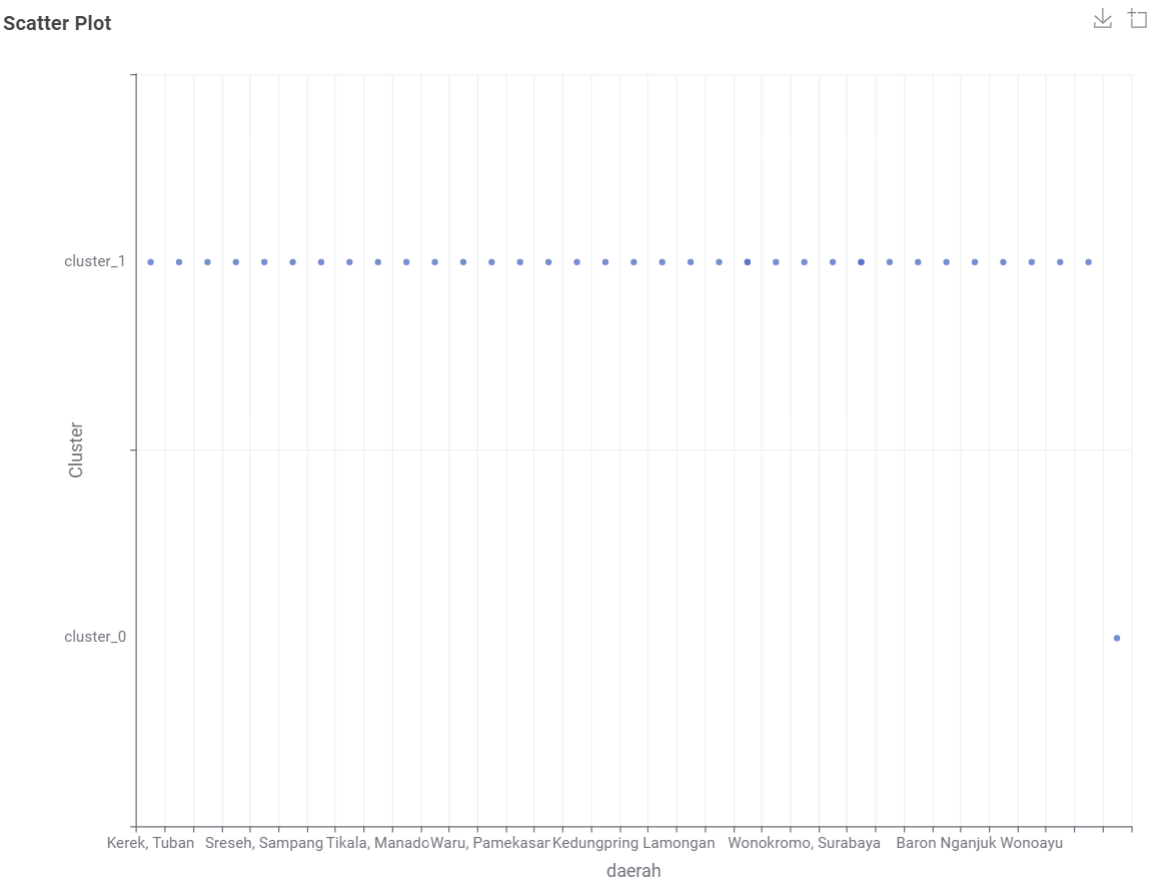

Berdasarkan Scatter Plot, hasil clustering polutan **SO2** terbagi menjadi **2 cluster**, yaitu **cluster_0** dan **cluster_1**. Persebaran titik menunjukkan bahwa jumlah anggota pada kedua cluster berbeda cukup jauh.

Beberapa hasil yang dapat diamati adalah:

- **Cluster_1** memiliki jumlah anggota paling banyak dan mencakup hampir seluruh daerah yang terdapat pada data.

- **Cluster_0** hanya memiliki satu anggota, yaitu **Wonoayu**, yang terlihat berada pada posisi berbeda dari daerah lainnya.

- Sumbu horizontal menunjukkan **daerah/kecamatan**, sedangkan sumbu vertikal menunjukkan **cluster** hasil pengelompokan K-Means.

Secara keseluruhan, hasil clustering SO2 menunjukkan bahwa sebagian besar data terkumpul pada **cluster_1**, sedangkan **Wonoayu** menjadi satu-satunya daerah yang berada pada **cluster_0**.

#### 1.5.3 Analisis Hasil Clustering Polutan CO

##### a. K = 2

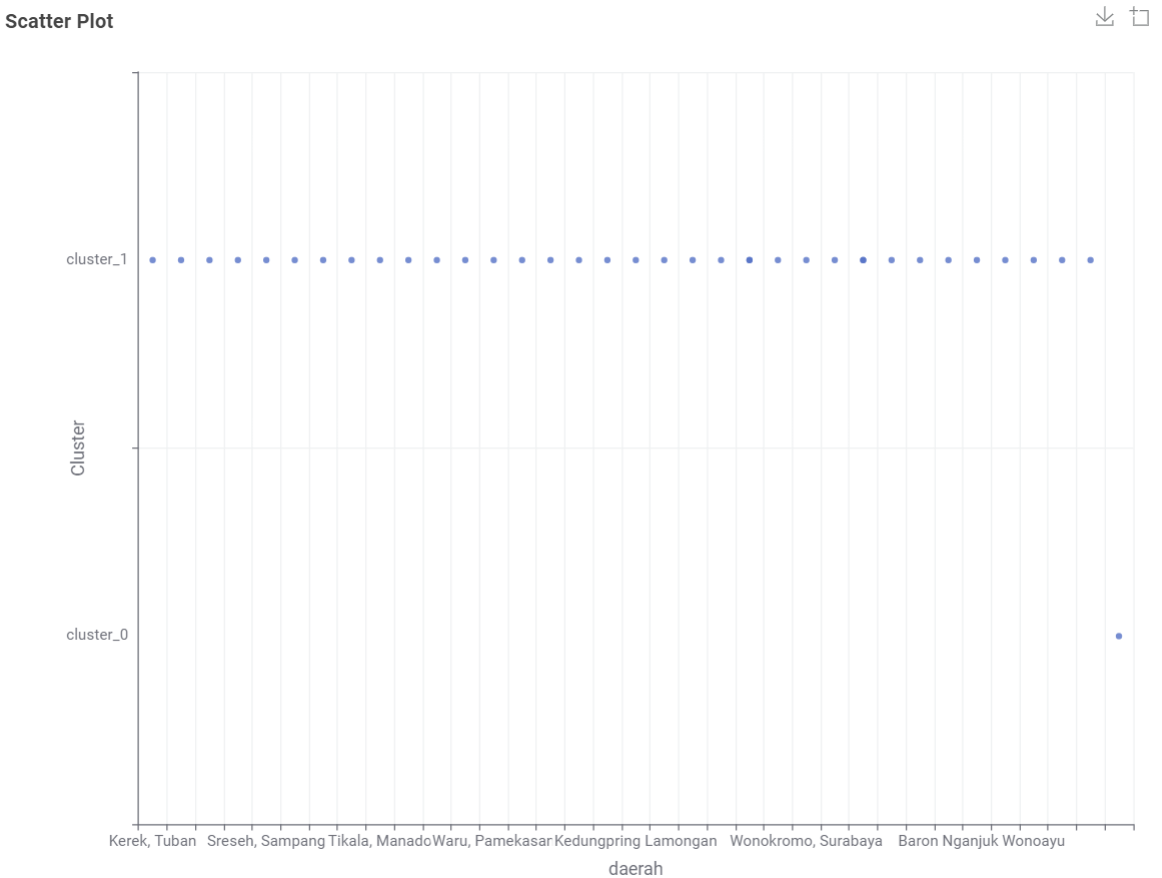

Berdasarkan Scatter Plot, hasil clustering polutan **CO** terbagi menjadi **2 cluster**, yaitu **cluster_0** dan **cluster_1**. Persebaran titik menunjukkan bahwa jumlah anggota pada kedua cluster berbeda cukup jauh.

Beberapa hasil yang dapat diamati adalah:

- **Cluster_1** memiliki jumlah anggota paling banyak dan mencakup hampir seluruh daerah yang terdapat pada data.

- **Cluster_0** hanya memiliki satu anggota, yaitu **Wonoayu**, yang terlihat berada pada posisi berbeda dari daerah lainnya.

- Sumbu horizontal menunjukkan **daerah/kecamatan**, sedangkan sumbu vertikal menunjukkan **cluster** hasil pengelompokan K-Means.

Secara keseluruhan, hasil clustering CO menunjukkan bahwa sebagian besar data terkumpul pada **cluster_1**, sedangkan **Wonoayu** menjadi satu-satunya daerah yang berada pada **cluster_0**.

## 2. Kesimpulan

Proses clustering K-Means pada data polutan Gresik dilakukan secara terpisah untuk **NO2, SO2, dan CO**, dengan evaluasi jumlah cluster $K=2$ sampai $K=10$ menggunakan Elbow Method dan Silhouette Score pada dua kondisi, yaitu **tanpa PCA (68 fitur)** dan **dengan PCA (37 komponen)**. Perbandingan kedua kondisi pada bagian 1.2.2 menunjukkan pengaruh reduksi dimensi terhadap kualitas pemisahan cluster untuk masing-masing polutan.

K-Means final dijalankan menggunakan K terbaik pada kondisi dengan PCA, kemudian hasilnya divisualisasikan melalui Scatter Plot serta dirangkum dalam bentuk distribusi jumlah anggota dan profil daerah pada tiap cluster. Cluster dengan jumlah anggota yang sedikit perlu diperhatikan secara khusus dalam interpretasi karena berpotensi memiliki karakteristik konsentrasi polutan yang berbeda dari kelompok lainnya.

Sebagai pembanding, implementasi clustering juga dilakukan menggunakan **KNIME** pada bagian 4.5, dengan alur pengolahan data yang serupa (standardisasi, PCA, dan K-Means) melalui data yang telah disimpan pada database PostgreSQL Aiven. Hasil visual dari KNIME dapat dibandingkan dengan hasil clustering menggunakan Python untuk melihat konsistensi pola pengelompokan pada masing-masing polutan.
